In [1]:
import numpy as np
import pandas as pd

#### Небольшое задание
- Создайте объект DataFrame и заполните его значениями площадей (в кв.км.) и количеством населения нескольких (не менеее пяти) областей РФ (данные можно брать из открытых источников, например из википедии);
- Рассчитайте плотность населения по каждой области и занесите эти данные в дополнительный столбец созданного вами объекта DataFrame;
- Опробуйте все методы индексирования и создания срезов для объектов DataFrame, которые мы обсудили в данном разделе.

In [4]:
area_dict = {'Тюменская область': 160122,
             'Алтайский край': 167996,
             'Архангельская область': 413103,
             'Республика Адыгея': 7792,
             'Амурская область': 361908}
area = pd.Series(area_dict)
area

Тюменская область        160122
Алтайский край           167996
Архангельская область    413103
Республика Адыгея          7792
Амурская область         361908
dtype: int64

In [5]:
population_dict = {'Тюменская область': 1626809,
             'Алтайский край': 2099186,
             'Архангельская область': 947528,
             'Республика Адыгея': 500731,
             'Амурская область': 753046}
population = pd.Series(population_dict)
population

Тюменская область        1626809
Алтайский край           2099186
Архангельская область     947528
Республика Адыгея         500731
Амурская область          753046
dtype: int64

In [6]:
regions = pd.DataFrame({'area': area,
                        'population': population})
regions

,area,population
Тюменская область,160122,1626809
Алтайский край,167996,2099186
Архангельская область,413103,947528
Республика Адыгея,7792,500731
Амурская область,361908,753046


In [7]:
regions['density'] = regions['population'] / regions['area']
regions

,area,population,density
Тюменская область,160122,1626809,10.159809
Алтайский край,167996,2099186,12.495452
Архангельская область,413103,947528,2.293685
Республика Адыгея,7792,500731,64.262192
Амурская область,361908,753046,2.080766


In [8]:
# Доступ по столбцу
regions['density']

Тюменская область        10.159809
Алтайский край           12.495452
Архангельская область     2.293685
Республика Адыгея        64.262192
Амурская область          2.080766
Name: density, dtype: float64

In [10]:
regions[::-1]

,area,population,density
Амурская область,361908,753046,2.080766
Республика Адыгея,7792,500731,64.262192
Архангельская область,413103,947528,2.293685
Алтайский край,167996,2099186,12.495452
Тюменская область,160122,1626809,10.159809


In [11]:
regions[0:3]

,area,population,density
Тюменская область,160122,1626809,10.159809
Алтайский край,167996,2099186,12.495452
Архангельская область,413103,947528,2.293685


In [13]:
regions.loc[:'Республика Адыгея', :'population']

,area,population
Тюменская область,160122,1626809
Алтайский край,167996,2099186
Архангельская область,413103,947528
Республика Адыгея,7792,500731


In [14]:
regions[regions['density'] > 5]

,area,population,density
Тюменская область,160122,1626809,10.159809
Алтайский край,167996,2099186,12.495452
Республика Адыгея,7792,500731,64.262192


In [15]:
pop = pd.read_csv('state-population.csv')
areas = pd.read_csv('state-areas.csv')
abbrevs = pd.read_csv('state-abbrevs.csv')

In [16]:
print(pop.head())
print(areas.head())
print(abbrevs.head())

  state/region     ages  year  population
0           AL  under18  2012   1117489.0
1           AL    total  2012   4817528.0
2           AL  under18  2010   1130966.0
3           AL    total  2010   4785570.0
4           AL  under18  2011   1125763.0
        state  area (sq. mi)
0     Alabama          52423
1      Alaska         656425
2     Arizona         114006
3    Arkansas          53182
4  California         163707
        state abbreviation
0     Alabama           AL
1      Alaska           AK
2     Arizona           AZ
3    Arkansas           AR
4  California           CA


In [26]:
merged = pd.merge(pop, abbrevs, how='outer', left_on='state/region',
                  right_on='abbreviation')

merged = merged.drop(columns='abbreviation') # Удаляем дублирующуюся информацию

merged.head()

,state/region,ages,year,population,state
0,AK,total,1990,553290.0,Alaska
1,AK,under18,1990,177502.0,Alaska
2,AK,total,1992,588736.0,Alaska
3,AK,under18,1991,182180.0,Alaska
4,AK,under18,1992,184878.0,Alaska


In [27]:
merged.isnull().any()

state/region    False
ages            False
year            False
population       True
state            True
dtype: bool

In [28]:
merged[merged['population'].isnull()].head()

,state/region,ages,year,population,state
1872,PR,under18,1990,NaN,NaN
1873,PR,total,1990,NaN,NaN
1874,PR,total,1991,NaN,NaN
1875,PR,under18,1991,NaN,NaN
1876,PR,total,1993,NaN,NaN


In [29]:
merged.loc[merged['state'].isnull(), 'state/region'].unique()

array(['PR', 'USA'], dtype=object)

In [30]:
merged.loc[merged['state/region'] == 'PR', 'state'] = 'Puerto Rico'
merged.loc[merged['state/region'] == 'USA', 'state'] = 'United States'
merged.isnull().any()

state/region    False
ages            False
year            False
population       True
state           False
dtype: bool

In [31]:
final = pd.merge(merged, areas, on='state', how='left')
final.head()

,state/region,ages,year,population,state,area (sq. mi)
0,AK,total,1990,553290.0,Alaska,656425.0
1,AK,under18,1990,177502.0,Alaska,656425.0
2,AK,total,1992,588736.0,Alaska,656425.0
3,AK,under18,1991,182180.0,Alaska,656425.0
4,AK,under18,1992,184878.0,Alaska,656425.0


In [32]:
final.isnull().any()

state/region     False
ages             False
year             False
population        True
state            False
area (sq. mi)     True
dtype: bool

In [33]:
final['state'][final['area (sq. mi)'].isnull()].unique()

array(['United States'], dtype=object)

In [34]:
final.dropna(inplace=True)
final.head()

,state/region,ages,year,population,state,area (sq. mi)
0,AK,total,1990,553290.0,Alaska,656425.0
1,AK,under18,1990,177502.0,Alaska,656425.0
2,AK,total,1992,588736.0,Alaska,656425.0
3,AK,under18,1991,182180.0,Alaska,656425.0
4,AK,under18,1992,184878.0,Alaska,656425.0


In [35]:
data2010 = final.query("year == 2010 & ages == 'total'")
data2010.head()

,state/region,ages,year,population,state,area (sq. mi)
43,AK,total,2010,713868.0,Alaska,656425.0
51,AL,total,2010,4785570.0,Alabama,52423.0
141,AR,total,2010,2922280.0,Arkansas,53182.0
149,AZ,total,2010,6408790.0,Arizona,114006.0
197,CA,total,2010,37333601.0,California,163707.0


In [36]:
data2010.set_index('state', inplace=True)
density = data2010['population'] / data2010['area (sq. mi)']
density.sort_values(ascending=False, inplace=True)
density.head()

state
District of Columbia    8898.897059
Puerto Rico             1058.665149
New Jersey              1009.253268
Rhode Island             681.339159
Connecticut              645.600649
dtype: float64

In [37]:
density.tail()

state
South Dakota    10.583512
North Dakota     9.537565
Montana          6.736171
Wyoming          5.768079
Alaska           1.087509
dtype: float64

In [38]:
import seaborn as sns
planets = sns.load_dataset('planets')
planets.shape

(1035, 6)

In [39]:
planets.head()

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009


In [40]:
planets.dropna().describe()

,number,orbital_period,mass,distance,year
count,498.00000,498.000000,498.000000,498.000000,498.000000
mean,1.73494,835.778671,2.509320,52.068213,2007.377510
std,1.17572,1469.128259,3.636274,46.596041,4.167284
min,1.00000,1.328300,0.003600,1.350000,1989.000000
25%,1.00000,38.272250,0.212500,24.497500,2005.000000
50%,1.00000,357.000000,1.245000,39.940000,2009.000000
75%,2.00000,999.600000,2.867500,59.332500,2011.000000
max,6.00000,17337.500000,25.000000,354.000000,2014.000000


In [41]:
planets.groupby('method')

In [42]:
planets.groupby('method')['orbital_period']

In [43]:
planets.groupby('method')['orbital_period'].median()

method
Astrometry                         631.180000
Eclipse Timing Variations         4343.500000
Imaging                          27500.000000
Microlensing                      3300.000000
Orbital Brightness Modulation        0.342887
Pulsar Timing                       66.541900
Pulsation Timing Variations       1170.000000
Radial Velocity                    360.200000
Transit                              5.714932
Transit Timing Variations           57.011000
Name: orbital_period, dtype: float64

In [45]:
for (method, group) in planets.groupby('method'):
    print('{0:30s} shape={1}'.format(method, group.shape))

Astrometry                     shape=(2, 6)
Eclipse Timing Variations      shape=(9, 6)
Imaging                        shape=(38, 6)
Microlensing                   shape=(23, 6)
Orbital Brightness Modulation  shape=(3, 6)
Pulsar Timing                  shape=(5, 6)
Pulsation Timing Variations    shape=(1, 6)
Radial Velocity                shape=(553, 6)
Transit                        shape=(397, 6)
Transit Timing Variations      shape=(4, 6)


In [46]:
planets.groupby('method')['year'].describe().unstack()

       method                       
count  Astrometry                          2.0
       Eclipse Timing Variations           9.0
       Imaging                            38.0
       Microlensing                       23.0
       Orbital Brightness Modulation       3.0
                                         ...  
max    Pulsar Timing                    2011.0
       Pulsation Timing Variations      2007.0
       Radial Velocity                  2014.0
       Transit                          2014.0
       Transit Timing Variations        2014.0
Length: 80, dtype: float64

In [50]:
# Вычисление десятилетий
decade = 10 * (planets['year'] // 10)
print(decade)

0       2000
1       2000
2       2010
3       2000
4       2000
        ... 
1030    2000
1031    2000
1032    2000
1033    2000
1034    2000
Name: year, Length: 1035, dtype: int64


In [52]:
# Формирование читаемой строки
decade = decade.astype('str') + 's'
print(decade)

0       2000s
1       2000s
2       2010s
3       2000s
4       2000s
        ...  
1030    2000s
1031    2000s
1032    2000s
1033    2000s
1034    2000s
Name: year, Length: 1035, dtype: object


In [54]:
# Переименовываем поле
decade.name = 'decade'

In [58]:
# Выполняем группировку и суммирование
grp_planets = planets.groupby(['method', decade])['number'].sum()
print(grp_planets)

method                         decade
Astrometry                     2010s       2
Eclipse Timing Variations      2000s       5
                               2010s      10
Imaging                        2000s      29
                               2010s      21
Microlensing                   2000s      12
                               2010s      15
Orbital Brightness Modulation  2010s       5
Pulsar Timing                  1990s       9
                               2000s       1
                               2010s       1
Pulsation Timing Variations    2000s       1
Radial Velocity                1980s       1
                               1990s      52
                               2000s     475
                               2010s     424
Transit                        2000s      64
                               2010s     712
Transit Timing Variations      2010s       9
Name: number, dtype: int64


In [61]:
# Преобразуем в DataFrame
grp_planets_df = grp_planets.unstack()
print(grp_planets_df)

decade                         1980s  1990s  2000s  2010s
method                                                   
Astrometry                       NaN    NaN    NaN    2.0
Eclipse Timing Variations        NaN    NaN    5.0   10.0
Imaging                          NaN    NaN   29.0   21.0
Microlensing                     NaN    NaN   12.0   15.0
Orbital Brightness Modulation    NaN    NaN    NaN    5.0
Pulsar Timing                    NaN    9.0    1.0    1.0
Pulsation Timing Variations      NaN    NaN    1.0    NaN
Radial Velocity                  1.0   52.0  475.0  424.0
Transit                          NaN    NaN   64.0  712.0
Transit Timing Variations        NaN    NaN    NaN    9.0


In [62]:
# Заполняем NaN значения нулями
grp_planets_df.fillna(0)

decade,1980s,1990s,2000s,2010s
method,,,,
Astrometry,0.0,0.0,0.0,2.0
Eclipse Timing Variations,0.0,0.0,5.0,10.0
Imaging,0.0,0.0,29.0,21.0
Microlensing,0.0,0.0,12.0,15.0
Orbital Brightness Modulation,0.0,0.0,0.0,5.0
Pulsar Timing,0.0,9.0,1.0,1.0
Pulsation Timing Variations,0.0,0.0,1.0,0.0
Radial Velocity,1.0,52.0,475.0,424.0
Transit,0.0,0.0,64.0,712.0


In [63]:
titanic = sns.load_dataset('titanic')

In [64]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [65]:
titanic.groupby('sex')[['survived']].mean()

,survived
sex,
female,0.742038
male,0.188908


In [66]:
titanic.groupby(['sex', 'class'])['survived'].aggregate('mean').unstack()

C:\Users\mihail\AppData\Local\Temp\ipykernel_18988\2603839867.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.groupby(['sex', 'class'])['survived'].aggregate('mean').unstack()


class,First,Second,Third
sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


In [67]:
titanic.pivot_table('survived', index='sex', columns='class')

C:\Users\mihail\AppData\Local\Temp\ipykernel_18988\1756680182.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table('survived', index='sex', columns='class')


class,First,Second,Third
sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


In [68]:
age = pd.cut(titanic['age'], [0, 18, 80])
titanic.pivot_table('survived', ['sex', age], 'class')

C:\Users\mihail\AppData\Local\Temp\ipykernel_18988\3418781527.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table('survived', ['sex', age], 'class')


class               First    Second     Third
sex    age                                   
female (0, 18]   0.909091  1.000000  0.511628
       (18, 80]  0.972973  0.900000  0.423729
male   (0, 18]   0.800000  0.600000  0.215686
       (18, 80]  0.375000  0.071429  0.133663

In [69]:
fare = pd.qcut(titanic['fare'], 2)
titanic.pivot_table('survived', ['sex', age], [fare, 'class'])

C:\Users\mihail\AppData\Local\Temp\ipykernel_18988\3929073192.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table('survived', ['sex', age], [fare, 'class'])


fare            (-0.001, 14.454]                     (14.454, 512.329]  \
class                      First    Second     Third             First   
sex    age                                                               
female (0, 18]               NaN  1.000000  0.714286          0.909091   
       (18, 80]              NaN  0.880000  0.444444          0.972973   
male   (0, 18]               NaN  0.000000  0.260870          0.800000   
       (18, 80]              0.0  0.098039  0.125000          0.391304   

fare                                 
class              Second     Third  
sex    age                           
female (0, 18]   1.000000  0.318182  
       (18, 80]  0.914286  0.391304  
male   (0, 18]   0.818182  0.178571  
       (18, 80]  0.030303  0.192308

In [70]:
titanic.pivot_table?

Signature:
titanic.pivot_table(
    values=None,
    index=None,
    columns=None,
    aggfunc: 'AggFuncType' = 'mean',
    fill_value=None,
    margins: 'bool' = False,
    dropna: 'bool' = True,
    margins_name: 'Level' = 'All',
    observed: 'bool | lib.NoDefault' = <no_default>,
    sort: 'bool' = True,
) -> 'DataFrame'
Docstring:
Create a spreadsheet-style pivot table as a DataFrame.

The levels in the pivot table will be stored in MultiIndex objects
(hierarchical indexes) on the index and columns of the result DataFrame.

Parameters
----------
values : list-like or scalar, optional
    Column or columns to aggregate.
index : column, Grouper, array, or list of the previous
    Keys to group by on the pivot table index. If a list is passed,
    it can contain any of the other types (except list). If an array is
    passed, it must be the same length as the data and will be used in
    the same manner as column values.
columns : column, Grouper, array, or list of the previous
    K

In [71]:
titanic.pivot_table(index='sex', columns='class',
                    aggfunc={'survived':sum, 'fare':'mean'})

C:\Users\mihail\AppData\Local\Temp\ipykernel_18988\392095072.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table(index='sex', columns='class',
C:\Users\mihail\AppData\Local\Temp\ipykernel_18988\392095072.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  titanic.pivot_table(index='sex', columns='class',


fare                       survived             
class        First     Second      Third    First Second Third
sex                                                           
female  106.125798  21.970121  16.118810       91     70    72
male     67.226127  19.741782  12.661633       45     17    47

In [72]:
titanic.pivot_table('survived', index='sex', columns='class', margins=True)

C:\Users\mihail\AppData\Local\Temp\ipykernel_18988\2270092574.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  titanic.pivot_table('survived', index='sex', columns='class', margins=True)


class,First,Second,Third,All
sex,,,,
female,0.968085,0.921053,0.500000,0.742038
male,0.368852,0.157407,0.135447,0.188908
All,0.629630,0.472826,0.242363,0.383838


In [73]:
births = pd.read_csv('births.csv')

In [74]:
births.head()

,year,month,day,gender,births
0,1969,1,1.0,F,4046
1,1969,1,1.0,M,4440
2,1969,1,2.0,F,4454
3,1969,1,2.0,M,4548
4,1969,1,3.0,F,4548


In [75]:
births['decade'] = 10 * (births['year'] // 10)
births.pivot_table('births', index='decade', columns='gender', aggfunc='sum')

gender,F,M
decade,,
1960,1753634,1846572
1970,16263075,17121550
1980,18310351,19243452
1990,19479454,20420553
2000,18229309,19106428


In [76]:
%matplotlib inline
import matplotlib.pyplot as plt
sns.set() # Используем стили библиотеки Seaborn

Text(0, 0.5, 'Общее количество новорожденных в течение года')

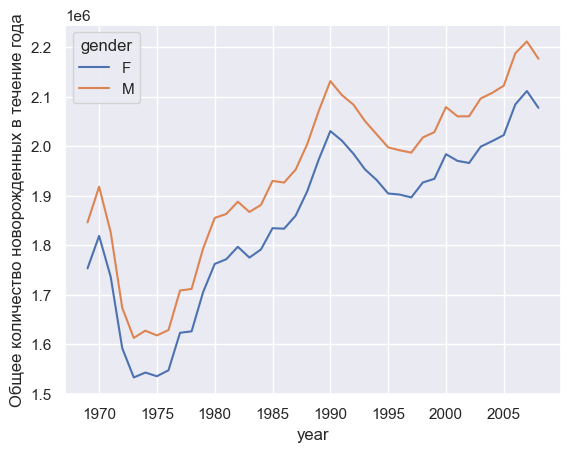

In [77]:
births.pivot_table('births', index='year', columns='gender', aggfunc='sum').plot()
plt.ylabel('Общее количество новорожденных в течение года')

In [78]:
quartiles = np.percentile(births['births'], [25, 50, 75])
mu = quartiles[1]
sig = 0.74 * (quartiles[2] - quartiles[0])

In [79]:
births = births.query('(births > @mu - 5 * @sig) & (births < @mu + 5 * @sig)')

In [80]:
# создаем индекс для даты из года, месяца и дня
births.index = pd.to_datetime(10000 * births.year + 
                              100 * births.month + 
                              births.day, format='%Y%m%d')
births['dayofweek'] = births.index.dayofweek # День недели

C:\Users\mihail\AppData\Local\Temp\ipykernel_18988\1632017929.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(['Пон', 'Вт', 'Ср', 'Чет', 'Пят','Суб','Воскр'])


Text(0, 0.5, 'Среднее количество новорожденных в день')

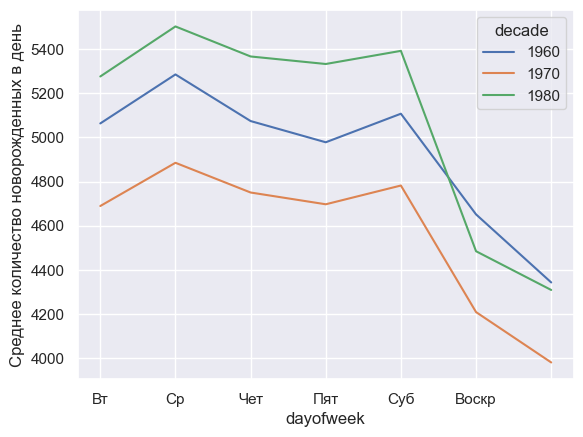

In [81]:
import matplotlib.pyplot as plt

births.pivot_table('births', index='dayofweek',
                   columns='decade', aggfunc='mean').plot()
plt.gca().set_xticklabels(['Пон', 'Вт', 'Ср', 'Чет', 'Пят','Суб','Воскр'])
plt.ylabel('Среднее количество новорожденных в день')

In [82]:
births_by_dayte = births.pivot_table('births', 
                                     [births.index.month, births.index.day])

In [83]:
births_by_dayte.head()

births
1 1  4009.225
  2  4247.400
  3  4500.900
  4  4571.350
  5  4603.625

In [96]:
births_by_dayte.index = [pd.datetime(2012, month, day) for (month, day) in births_by_dayte.index]

TypeError: cannot unpack non-iterable Timestamp object

In [97]:
births_by_dayte.head()

,births
2012-01-01,4009.225
2012-01-02,4247.400
2012-01-03,4500.900
2012-01-04,4571.350
2012-01-05,4603.625


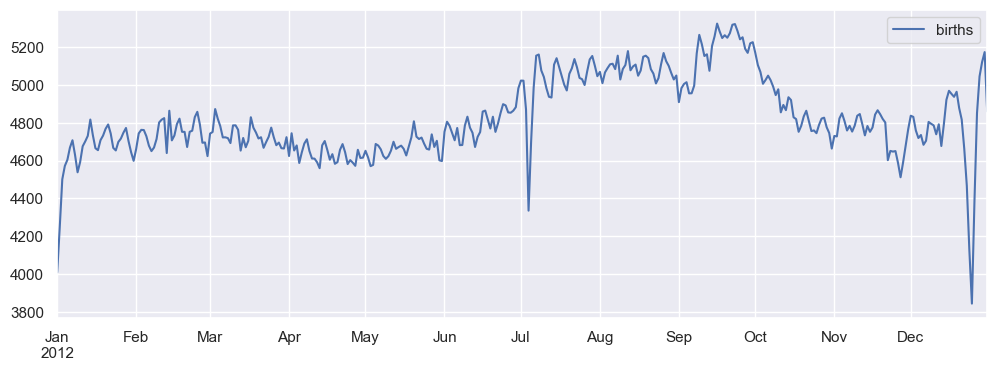

In [98]:
# Строим график результатов
fig, ax = plt.subplots(figsize=(12, 4))
births_by_dayte.plot(ax=ax);

In [99]:
from datetime import datetime
datetime(year=2016, month=10, day=12)

datetime.datetime(2016, 10, 12, 0, 0)

In [101]:
from dateutil import parser
date = parser.parse('12th of October, 2016')
date

datetime.datetime(2016, 10, 12, 0, 0)

In [102]:
date.strftime('%A')

'Wednesday'

In [103]:
date = np.array('2016-05-23', dtype=np.datetime64)
date

array('2016-05-23', dtype='datetime64[D]')

In [104]:
date + np.arange(12)

array(['2016-05-23', '2016-05-24', '2016-05-25', '2016-05-26',
       '2016-05-27', '2016-05-28', '2016-05-29', '2016-05-30',
       '2016-05-31', '2016-06-01', '2016-06-02', '2016-06-03'],
      dtype='datetime64[D]')

In [106]:
date = pd.to_datetime('23rd of May, 2019')
date

Timestamp('2019-05-23 00:00:00')

In [107]:
date.strftime('%A')

'Thursday'

In [108]:
date + pd.to_timedelta(np.arange(12), 'D')

DatetimeIndex(['2019-05-23', '2019-05-24', '2019-05-25', '2019-05-26',
               '2019-05-27', '2019-05-28', '2019-05-29', '2019-05-30',
               '2019-05-31', '2019-06-01', '2019-06-02', '2019-06-03'],
              dtype='datetime64[ns]', freq=None)

In [109]:
index = pd.DatetimeIndex(['2014-01-01', '2016-10-13', '2019-05-23',  '2019-06-19'])
data = pd.Series([0, 1, 2, 3], index=index)
data

2014-01-01    0
2016-10-13    1
2019-05-23    2
2019-06-19    3
dtype: int64

In [110]:
data['2014-01-01':'2019-05-23']

2014-01-01    0
2016-10-13    1
2019-05-23    2
dtype: int64

In [111]:
data['2019']

2019-05-23    2
2019-06-19    3
dtype: int64

In [112]:
dates = pd.to_datetime([datetime(2013, 10, 18), '19th of October, 2013',
                        '2013-Oct-20', '21-10-2013', '20131022'])
dates

DatetimeIndex(['2013-10-18', '2013-10-19', '2013-10-20', '2013-10-21',
               '2013-10-22'],
              dtype='datetime64[ns]', freq=None)

In [113]:
dates.to_period('D')

PeriodIndex(['2013-10-18', '2013-10-19', '2013-10-20', '2013-10-21',
             '2013-10-22'],
            dtype='period[D]')

In [114]:
dates - dates[0]

TimedeltaIndex(['0 days', '1 days', '2 days', '3 days', '4 days'], dtype='timedelta64[ns]', freq=None)

In [115]:
pd.date_range('2020-11-01', '2020-11-14')

DatetimeIndex(['2020-11-01', '2020-11-02', '2020-11-03', '2020-11-04',
               '2020-11-05', '2020-11-06', '2020-11-07', '2020-11-08',
               '2020-11-09', '2020-11-10', '2020-11-11', '2020-11-12',
               '2020-11-13', '2020-11-14'],
              dtype='datetime64[ns]', freq='D')

In [116]:
pd.date_range('2020-11-01', periods=7)

DatetimeIndex(['2020-11-01', '2020-11-02', '2020-11-03', '2020-11-04',
               '2020-11-05', '2020-11-06', '2020-11-07'],
              dtype='datetime64[ns]', freq='D')

In [117]:
pd.date_range('2020-11-04 08:00:00', periods=8, freq='H')

C:\Users\mihail\AppData\Local\Temp\ipykernel_18988\59622709.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  pd.date_range('2020-11-04 08:00:00', periods=8, freq='H')


DatetimeIndex(['2020-11-04 08:00:00', '2020-11-04 09:00:00',
               '2020-11-04 10:00:00', '2020-11-04 11:00:00',
               '2020-11-04 12:00:00', '2020-11-04 13:00:00',
               '2020-11-04 14:00:00', '2020-11-04 15:00:00'],
              dtype='datetime64[ns]', freq='h')

In [118]:
data = pd.read_csv('Fremont_Bridge_Bicycle_Counter.csv', index_col='Date', parse_dates=True)
data.head()

C:\Users\mihail\AppData\Local\Temp\ipykernel_18988\3181745616.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv('Fremont_Bridge_Bicycle_Counter.csv', index_col='Date', parse_dates=True)


,Fremont Bridge Total,Fremont Bridge East Sidewalk,Fremont Bridge West Sidewalk
Date,,,
2012-10-03 00:00:00,13.0,4.0,9.0
2012-10-03 01:00:00,10.0,4.0,6.0
2012-10-03 02:00:00,2.0,1.0,1.0
2012-10-03 03:00:00,5.0,2.0,3.0
2012-10-03 04:00:00,7.0,6.0,1.0


In [119]:
data.dropna().describe()

,Fremont Bridge Total,Fremont Bridge East Sidewalk,Fremont Bridge West Sidewalk
count,136313.000000,136313.000000,136313.000000
mean,112.975065,51.514060,61.461005
std,143.607191,66.214446,89.406687
min,0.000000,0.000000,0.000000
25%,14.000000,6.000000,7.000000
50%,61.000000,28.000000,30.000000
75%,148.000000,69.000000,75.000000
max,1097.000000,698.000000,850.000000


In [120]:
%matplotlib inline
import seaborn; seaborn.set()

Text(0, 0.5, 'Количество велосипедов по часам')

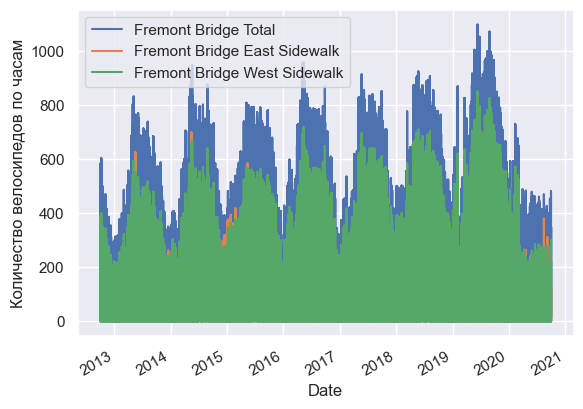

In [121]:
data.plot()
plt.ylabel('Количество велосипедов по часам')

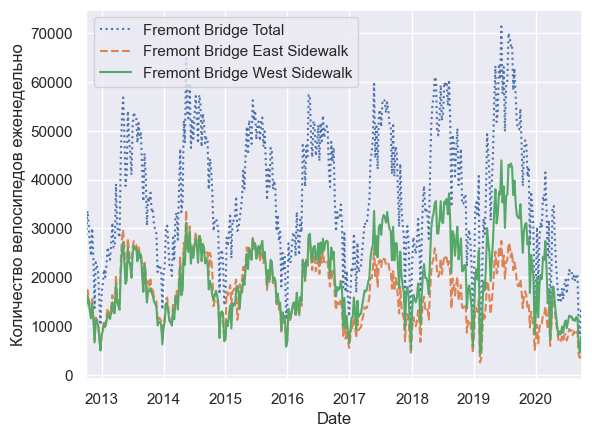

In [122]:
weekly = data.resample('W').sum()
weekly.plot(style=[':', '--', '-'])
plt.ylabel('Количество велосипедов еженедельно');

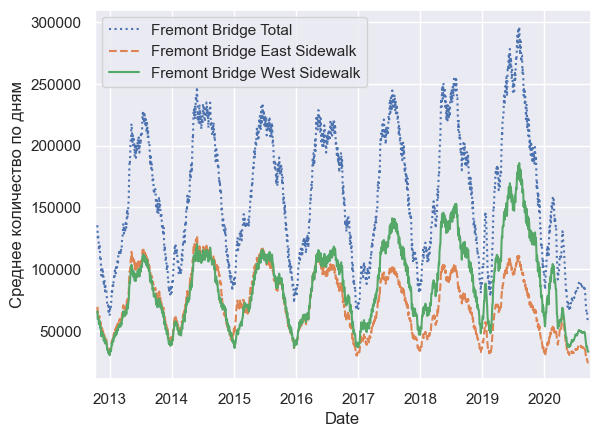

In [123]:
daily = data.resample('D').sum()
daily.rolling(30, center=True).sum().plot(style=[':', '--', '-'])
plt.ylabel('Среднее количество по дням');

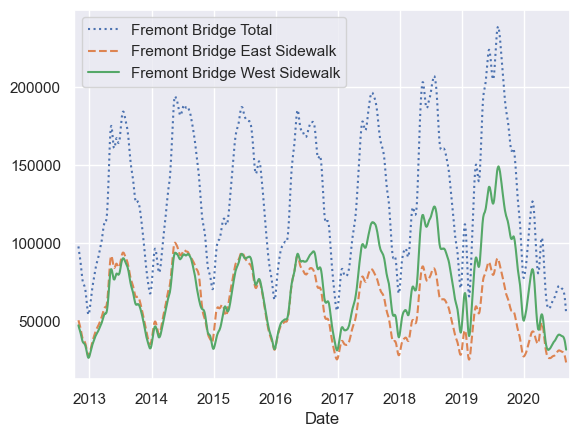

In [124]:
daily.rolling(50, center=True, win_type='gaussian').sum(std=10).plot(style=[':', '--', '-']);

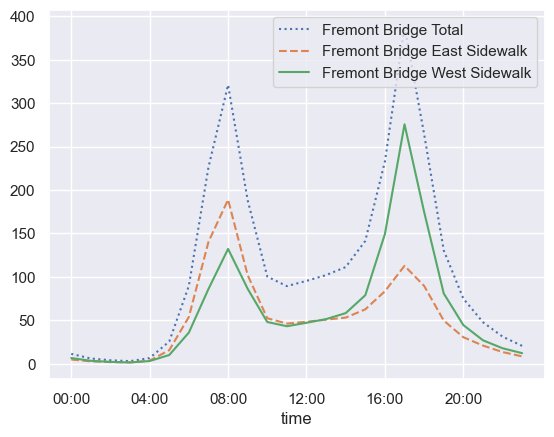

In [125]:
by_time = data.groupby(data.index.time).mean()
hourly_ticks = 4 * 60 * 60 * np.arange(6)
by_time.plot(xticks=hourly_ticks, style=[':', '--', '-']);

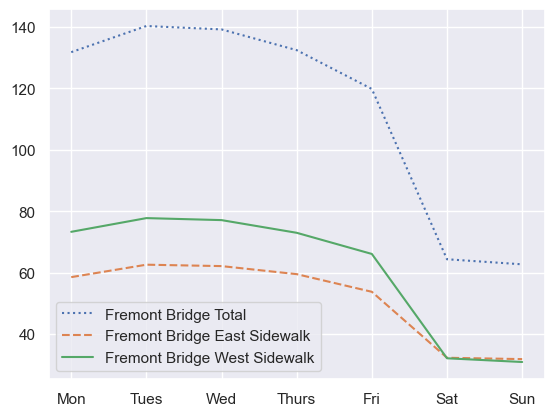

In [126]:
by_weekday = data.groupby(data.index.dayofweek).mean()
by_weekday.index = ['Mon', 'Tues', 'Wed', 'Thurs',
                    'Fri', 'Sat', 'Sun']
by_weekday.plot(style=[':', '--', '-']);

In [127]:
weekend = np.where(data.index.weekday < 5, 'Weekday', 'Weekend')
by_time = data.groupby([weekend, data.index.time]).mean()

AttributeError: 'DataFrame' object has no attribute 'ix'

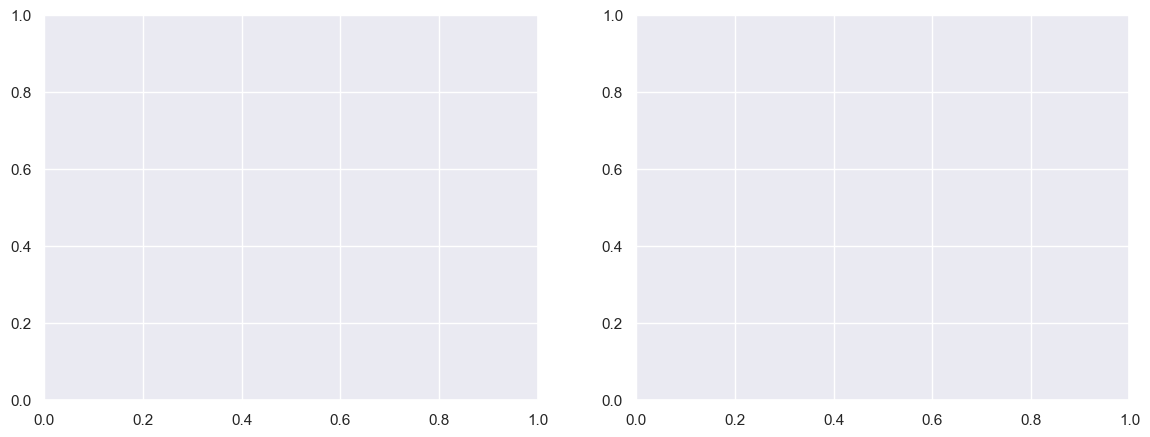

In [128]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
by_time.ix['Weekday'].plot(ax=ax[0], title='Weekdays',
                           xticks=hourly_ticks, style=[':', '--', '-'])
by_time.ix['Weekend'].plot(ax=ax[1], title='Weekends',
                           xticks=hourly_ticks, style=[':', '--', '-']);

In [131]:
rng = np.random.RandomState(42)
x = rng.rand(1000000)
y = rng.rand(1000000)
 
%timeit x + y

4.41 ms ± 147 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [132]:
tmp1 = (x > 0.5)
tmp2 = (y < 0.5)
mask = tmp1 & tmp2

In [133]:
import numexpr

mask_numexpr = numexpr.evaluate('(x > 0.5) & (y < 0.5)')
np.allclose(mask, mask_numexpr)

True

In [134]:
nrows, ncols = 100000, 100
rng = np.random.RandomState(42)
df1, df2, df3, df4 = (pd.DataFrame(rng.rand(nrows, ncols)) for i in range(4))

In [137]:
np.allclose(df1 + df2 + df3 + df4,
            pd.eval('df1 + df2 + df3 + df4'))

True